# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

In [ ]:
# Import pandas library for data manipulation and analysis
import pandas as pd

# Import numpy library for numerical operations
import numpy as np

# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt

# Import seaborn for advanced statistical data visualization (built on top of matplotlib)
import seaborn as sns


# -------------------------------
# Set consistent styling for plots
# -------------------------------

# Set seaborn style to "whitegrid"
# This adds a clean white background with grid lines (good for readability)
sns.set_style("whitegrid")

# Set default figure size for all plots (width=10, height=6 inches)
plt.rcParams['figure.figsize'] = (10, 6)

# Set default font size for all plot text (titles, labels, ticks, etc.)
plt.rcParams['font.size'] = 12

In [ ]:
# URL of the dataset (Superstore sales data)
# This dataset is hosted on GitHub and contains retail sales information
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"

try:
    # Try to load the dataset directly from the URL
    # pd.read_csv() reads CSV files into a pandas DataFrame
    # encoding='latin-1' is used because some characters in this dataset are not UTF-8
    df = pd.read_csv(url, encoding='latin-1')

    # Print number of rows and columns to confirm successful loading
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

except Exception as e:
    # If loading from URL fails (e.g., internet issue), this block runs
    print(f"URL failed ({e}). Upload your CSV manually.")

    # Import file upload tool from Google Colab
    from google.colab import files

    # Let user upload file manually from their computer
    uploaded = files.upload()

    # Get the uploaded file name
    filename = list(uploaded.keys())[0]

    # Read the uploaded CSV file into a DataFrame
    df = pd.read_csv(filename, encoding='latin-1')

    # Print confirmation after successful upload
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Show first 3 rows of the dataset to get a quick preview
df.head(3)

In [ ]:
# -------------------------------
# Quick data preparation step
# -------------------------------

# We are trying to find columns that contain dates in their names
# Example: "Order Date", "Ship Date", etc.

# Create a list of column names that include the word "date" (case-insensitive)
date_cols = [c for c in df.columns if 'date' in c.lower()]

# Loop through each detected date column
for col in date_cols:

    # Convert the column to datetime format
    # pd.to_datetime() changes text values into proper date format
    # errors='coerce' means:
    # - invalid values will become NaT (Not a Time) instead of crashing the code
    df[col] = pd.to_datetime(df[col], errors='coerce')

    # Print confirmation for each converted column
    print(f"Converted {col} to datetime")


# -------------------------------
# Inspect dataset structure
# -------------------------------

# Print all column names in the dataset
# This helps us understand what variables we are working with
print(f"\nColumns: {list(df.columns)}")

---
## 1. Histogram: Distribution of Sales

A histogram shows how values are distributed. Is the data symmetric? Skewed? Are there clusters?

In [ ]:
# ---------------------------------------
# Find the sales column in the dataset
# ---------------------------------------

# We search for a column that contains the word "sales"
# This makes the code flexible because some datasets may use "Sales" or "sales"
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]


# ---------------------------------------
# Create figure and axis for plotting
# ---------------------------------------

# fig = entire figure (canvas)
# ax = single plot area inside the figure
# figsize controls width and height of the chart
fig, ax = plt.subplots(figsize=(10, 6))


# ---------------------------------------
# Create histogram of sales values
# ---------------------------------------

# df[sales_col] -> selects the sales column from the DataFrame
# bins=50 -> divides data into 50 intervals (bars)
# edgecolor='black' -> adds border to bars for clarity
# alpha=0.7 -> makes bars slightly transparent
# color='steelblue' -> sets bar color
ax.hist(df[sales_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')


# ---------------------------------------
# Labeling the plot
# ---------------------------------------

# X-axis label
ax.set_xlabel('Sales ($)')

# Y-axis label
ax.set_ylabel('Frequency')

# Title of the chart
ax.set_title('Distribution of Sales')


# ---------------------------------------
# Add reference lines (mean and median)
# ---------------------------------------

# Mean line (average sales)
ax.axvline(
    df[sales_col].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: ${df[sales_col].mean():,.0f}'
)

# Median line (middle value of sales)
ax.axvline(
    df[sales_col].median(),
    color='orange',
    linestyle='--',
    label=f'Median: ${df[sales_col].median():,.0f}'
)

# Show legend (labels for mean and median lines)
ax.legend()


# ---------------------------------------
# Improve layout spacing
# ---------------------------------------

# Prevents overlapping of labels and plot elements
plt.tight_layout()


# Display the plot
plt.show()


# ---------------------------------------
# Interpretation of the graph
# ---------------------------------------

print(f"Interpretation: The distribution is right-skewed -- most orders are small,")
print(f"with a long tail of high-value orders. Mean > Median confirms the skew.")

---
## 2. Boxplot: Profit Distribution

A boxplot shows the quartiles (25th, 50th, 75th percentile) and outliers.

In [ ]:
# ---------------------------------------
# Find the profit column in the dataset
# ---------------------------------------

# We search for a column that contains the word "profit"
# This makes the code flexible across different dataset versions
profit_col = [c for c in df.columns if 'profit' in c.lower()][0]


# ---------------------------------------
# Create boxplot figure
# ---------------------------------------

# fig = overall figure (canvas)
# ax = area where the plot is drawn
# figsize=(8,6) sets width and height of the plot
fig, ax = plt.subplots(figsize=(8, 6))


# ---------------------------------------
# Create boxplot of profit values
# ---------------------------------------

# df[profit_col].dropna() removes missing values (NaN) before plotting

bp = ax.boxplot(
    df[profit_col].dropna(),
    vert=True,              # vertical boxplot
    patch_artist=True,      # allows coloring of the box
    boxprops=dict(facecolor='lightblue', color='navy'),  # box color + border
    medianprops=dict(color='red', linewidth=2)           # median line styling
)


# ---------------------------------------
# Label the plot
# ---------------------------------------

# Y-axis label
ax.set_ylabel('Profit ($)')

# Title of the chart
ax.set_title('Boxplot of Profit')


# Improve spacing to avoid overlapping elements
plt.tight_layout()

# Show the plot
plt.show()


# ---------------------------------------
# Outlier detection using IQR method
# ---------------------------------------

# Q1 = 25th percentile (lower quartile)
Q1 = df[profit_col].quantile(0.25)

# Q3 = 75th percentile (upper quartile)
Q3 = df[profit_col].quantile(0.75)

# IQR = Interquartile Range (middle 50% of data)
IQR = Q3 - Q1

# Lower boundary for outliers (anything below this is an outlier)
lower_bound = Q1 - 1.5 * IQR

# Upper boundary for outliers (anything above this is an outlier)
upper_bound = Q3 + 1.5 * IQR


# ---------------------------------------
# Count number of outliers
# ---------------------------------------

# A value is an outlier if it is below lower_bound OR above upper_bound
n_outliers = ((df[profit_col] < lower_bound) | (df[profit_col] > upper_bound)).sum()


# ---------------------------------------
# Print statistical summary
# ---------------------------------------

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")

print(f"Outlier boundaries: [{lower_bound:,.2f}, {upper_bound:,.2f}]")

print(f"Number of outliers: {n_outliers} ({n_outliers/len(df):.1%} of data)")

---
## 3. Bar Chart: Sales by Category

Compare total sales across product categories.

In [ ]:
# ---------------------------------------
# Find the category column in the dataset
# ---------------------------------------

# Search for any column that contains the word "category"
# This helps handle different dataset versions (e.g., "Category", "Sub-Category")
category_col = [c for c in df.columns if 'category' in c.lower()]

# Choose the first matching column if it exists
# If no such column is found, set it to None
cat_col = category_col[0] if category_col else None


# ---------------------------------------
# Proceed only if a category column exists
# ---------------------------------------

if cat_col:

    # Group data by category and calculate total sales for each category
    # groupby(cat_col) → splits data into categories
    # [sales_col].sum() → sums sales within each category
    # sort_values(ascending=False) → sorts from highest to lowest sales
    cat_sales = df.groupby(cat_col)[sales_col].sum().sort_values(ascending=False)


    # ---------------------------------------
    # Create bar chart
    # ---------------------------------------

    # Set figure size (width=8, height=5)
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create bar chart
    # cat_sales.index → category names
    # cat_sales.values → total sales values
    # color → manually set colors for bars
    # edgecolor → adds black borders for better visibility
    bars = ax.bar(
        cat_sales.index,
        cat_sales.values,
        color=['#2196F3', '#4CAF50', '#FF9800'],
        edgecolor='black'
    )


    # ---------------------------------------
    # Add value labels on top of bars
    # ---------------------------------------

    # Loop through each bar and its value
    for bar, val in zip(bars, cat_sales.values):

        # Place text slightly above each bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # center of bar (x-position)
            bar.get_height() + 5000,            # slightly above bar (y-position)
            f'${val:,.0f}',                      # formatted sales value
            ha='center',                         # horizontal alignment
            va='bottom',                         # vertical alignment
            fontweight='bold'                    # bold text
        )


    # ---------------------------------------
    # Labeling the chart
    # ---------------------------------------

    ax.set_xlabel('Category')              # X-axis label
    ax.set_ylabel('Total Sales ($)')       # Y-axis label
    ax.set_title('Total Sales by Category')# Chart title


    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Display the plot
    plt.show()


else:
    # If no category column is found, show warning message
    print("No 'Category' column found. Check column names above.")

---
## 4. Correlation Heatmap

Shows how numerical features relate to each other. Values range from -1 (perfect negative) to +1 (perfect positive).

In [ ]:
# ---------------------------------------
# Select only numerical columns
# ---------------------------------------

# df.select_dtypes(include=[np.number])
# This keeps only columns with numeric data (int, float)
# Correlation only works with numbers, not text
num_df = df.select_dtypes(include=[np.number])


# ---------------------------------------
# Remove ID-like columns
# ---------------------------------------

# Some numeric columns are not useful for correlation analysis
# Examples: Row ID, Postal Code, ZIP codes, etc.
# These do not represent real relationships between variables

id_like = [
    c for c in num_df.columns
    if any(kw in c.lower() for kw in ['id', 'postal', 'code', 'zip'])
]

# Drop those irrelevant columns safely (errors='ignore' prevents crashes if not found)
num_df = num_df.drop(columns=id_like, errors='ignore')


# ---------------------------------------
# Compute correlation matrix
# ---------------------------------------

# corr() calculates pairwise correlation between all numeric features
# Values range from:
# +1 → strong positive relationship
#  0 → no relationship
# -1 → strong negative relationship
corr_matrix = num_df.corr()


# ---------------------------------------
# Create heatmap visualization
# ---------------------------------------

# fig = canvas, ax = plotting area
fig, ax = plt.subplots(figsize=(8, 6))

# sns.heatmap() creates a color-coded correlation matrix
sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside cells
    fmt='.2f',           # format numbers to 2 decimal places
    cmap='RdBu_r',       # red-blue color scheme (red = negative, blue = positive)
    center=0,            # center color scale at 0
    square=True,         # make cells square-shaped
    linewidths=0.5,      # add thin grid lines between cells
    ax=ax                # plot on this axis
)


# ---------------------------------------
# Label the plot
# ---------------------------------------

ax.set_title('Correlation Heatmap (Numerical Features)')


# Improve layout spacing
plt.tight_layout()

# Show plot
plt.show()


# ---------------------------------------
# Interpretation guide
# ---------------------------------------

print("Interpretation:")
print("- Look for strong positive correlations (close to +1): features that move together.")
print("- Look for strong negative correlations (close to -1): features that move opposite.")
print("- Remember: correlation does not imply causation.")

---
## 5. Time Series: Monthly Sales Trend

Track how total sales change over time. Look for seasonality and trends.

In [ ]:
# ---------------------------------------
# Find the order date column
# ---------------------------------------

# We search for a column that contains BOTH:
# - "order" (to identify order-related data)
# - "date" (to ensure it's a date column)
order_date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]


# ---------------------------------------
# Proceed only if such a column exists
# ---------------------------------------

if order_date_col:

    # Select the first matching column (usually "Order Date")
    odate = order_date_col[0]


    # ---------------------------------------
    # Resample data by month
    # ---------------------------------------

    # set_index(odate) → makes date column the index
    # [sales_col] → selects sales values
    # resample('M') → groups data by month-end frequency
    # sum() → calculates total sales per month
    monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()


    # ---------------------------------------
    # Create time series plot
    # ---------------------------------------

    # figsize=(12,5) → wider plot for time series readability
    fig, ax = plt.subplots(figsize=(12, 5))

    # Line plot of monthly sales
    ax.plot(
        monthly_sales.index,        # dates (x-axis)
        monthly_sales.values,       # sales values (y-axis)
        color='steelblue',          # line color
        linewidth=2,                # thickness of line
        marker='o',                 # show points on line
        markersize=3                # size of each point
    )


    # ---------------------------------------
    # Label the plot
    # ---------------------------------------

    ax.set_xlabel('Date')              # X-axis label
    ax.set_ylabel('Total Sales ($)')   # Y-axis label
    ax.set_title('Monthly Total Sales Over Time')  # Title


    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)


    # Improve layout spacing
    plt.tight_layout()

    # Show plot
    plt.show()


    # ---------------------------------------
    # Interpretation guide
    # ---------------------------------------

    print("Look for:")
    print("- Overall trend (going up, down, or flat?)")
    print("- Seasonal patterns (spikes at certain times of year?)")
    print("- Anomalies (sudden drops or spikes?)")

else:
    # If no matching date column is found
    print("No order date column found. Check column names.")

---
## TODO: Create 2 Additional Plots

Create 2 plots that were NOT shown above. Some ideas:
- Scatter plot of Sales vs Profit
- Bar chart of Sales by Region
- Pie chart of order count by Segment (Consumer, Corporate, Home Office)
- Violin plot or histogram of Discount distribution
- Stacked bar chart by Category and Sub-Category

For each plot:
1. Write the code
2. Add title and axis labels
3. Write 2-3 sentences of interpretation in a markdown cell below the plot

In [ ]:
# TODO: Plot 1
# Your code here:


*TODO: Write your interpretation of Plot 1 here.*

In [ ]:
# TODO: Plot 2
# Your code here:


*TODO: Write your interpretation of Plot 2 here.*

---
## Reflection

Answer in a text cell below:

1. The Sales histogram is right-skewed. Why does this happen in retail data? What would it mean if it were perfectly normal?
2. You found outliers in Profit. Should you remove them? What information might you lose?
3. If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?

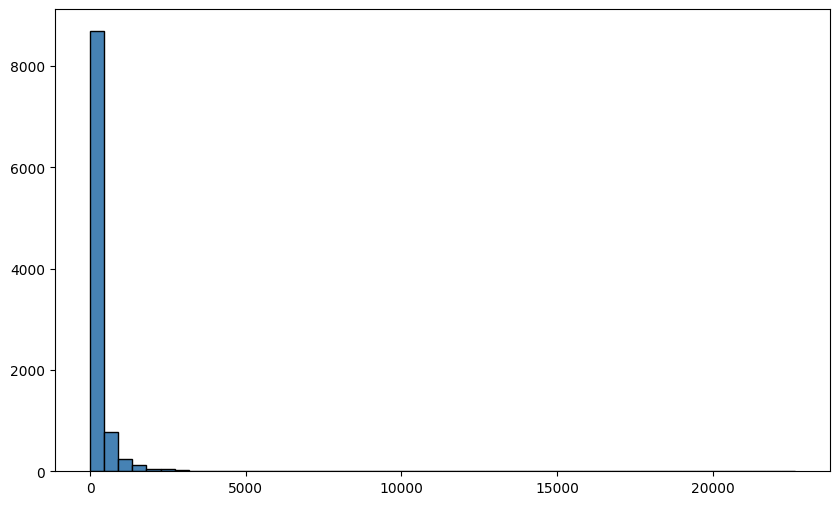

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('superstore_cleaned.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title = ('Distribution of sales')
plt.xlabel = ('Sales ($)')
plt.ylabel = ('Frequency')
plt.show()

**The sales distribution is
right-skewed. Most of the sales values are small, and only a few orders have very high sales. This shows that high-value purchases are rare in the dataset.**

The Sales histogram is likely right-skewed. Why does this happen in retail data?
Right-skewness happens because most retail transactions are for small, everyday items (low value), creating a tall peak on the left. High-value sales (like furniture or expensive electronics) occur much less frequently, creating a "long tail" that stretches to the right.

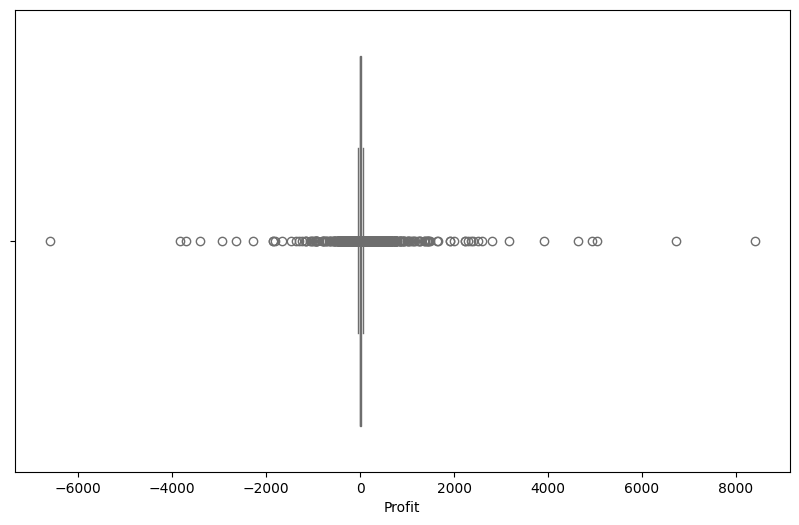

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title = ('Boxplot of Profit')
plt.xlabel = ('Profit ($)')
plt.show()

The median profit is around the middle of the box, with Q1 and Q3 showing the lower and upper 25% range of values. There are several visible outliers, meaning some orders have unusually high or low profit compared to most data points.



Outliers often represent significant business events, such as massive bulk orders or major returns. Removing them would hide the reality of your most profitable customers or your most critical operational failures.

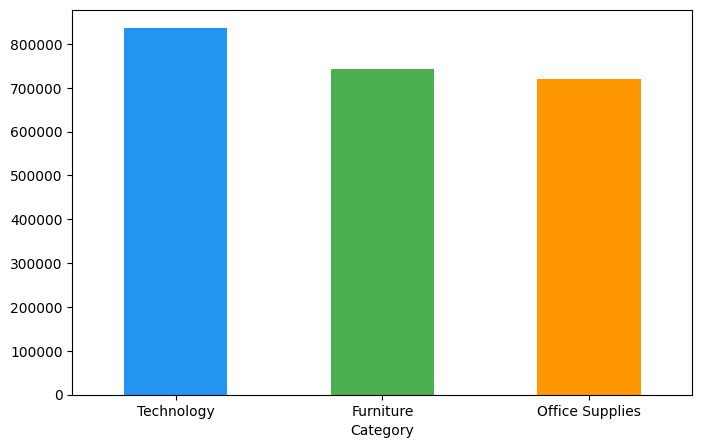

In [12]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title = ('Total Sales by Category')
plt.xlabel = ('Category')
plt.ylabel = ('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

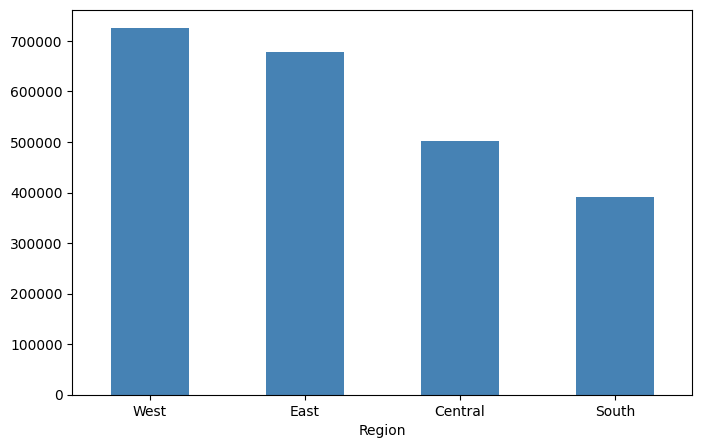

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title = ('Total Sales by Region')
plt.xlabel = ('Region')
plt.ylabel = ('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

Technology and the West region generate the most revenue. A noticeable observation is that some categories or regions contribute much less, which may indicate differences in demand or market size.

In [17]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR= Q3 - Q1
print(f'Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}')

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(f'Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*2:.2%})')

Q1: 1.73, Q3: 29.36, IQR: 27.64
Lower bound: -39.72, Upper bound: 70.82
Number of outliers: 1881 out of 9994 rows (37.64%)


I found 1881 outliers in the dataset. These are mostly high-profit  items. Specifically, there are High-profit Count items above the upper bound representing significant gains, and High-loss Count items below the lower bound representing significant losses.

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


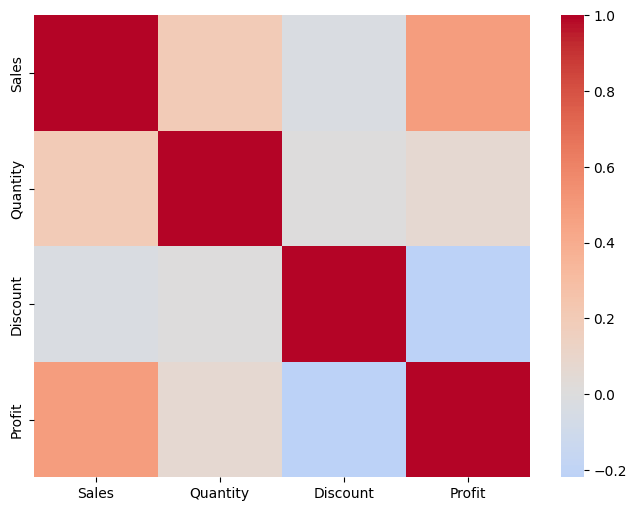

In [19]:
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title = ('Correlation Heatmao: Sales , Quantity, Discount, Profit')
plt.show()

Strongest positive correlation: The pair with the strongest positive correlation is Sales and Profit (0.48). This suggests that as sales increase, profit generally tends to increase as well.

Negative relationships: Yes, there are negative relationships. Specifically, Discount has a negative correlation with both Profit (-0.22) and Sales (-0.03).

Discount-Profit suggestion: The negative correlation of -0.22 between Discount and Profit suggests that higher discounts are associated with lower profits. This likely means that aggressive discounting is cutting into the company's bottom line.

While discounts may reduce the profit margin per item, they are often used to drive higher sales volume, clear old inventory, or acquire new customers. Stopping discounts might increase profit per unit but could lead to a drastic drop in total revenue.

/tmp/ipykernel_6235/2660581725.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


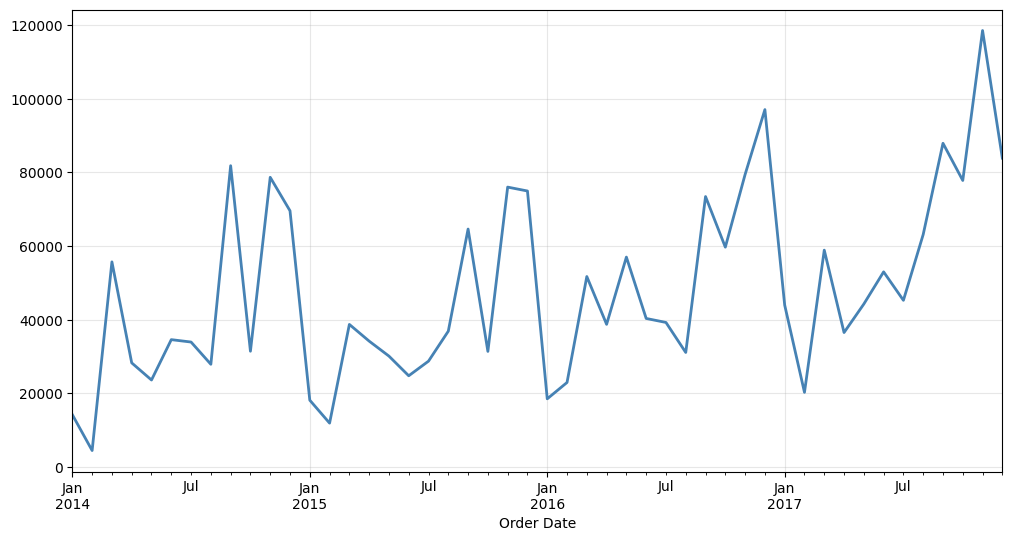

In [21]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title = ('Monthly Total Sales Over Time')
plt.xlabel = ('Month')
plt.ylabel = ('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

Seasonal Patterns: Yes, there are clear seasonal patterns. Sales consistently show significant spikes at the end of each year (November and December), which corresponds to the holiday shopping season.

Notable Dips: There is a recurring, sharp dip at the beginning of every year (specifically in January/February). After the holiday peak, sales drop significantly before beginning a gradual recovery throughout the spring and summer months.

Overall Trend: Beyond the seasonality, there is a general upward trend over the years, as the peaks in 2016 and 2017 are higher than the peak in 2014.

Based on the end-of-year spikes, I would increase staffing and inventory levels in October to prepare for the holiday rush. Additionally, since sales consistently dip in January, I would plan marketing campaigns or "New Year" sales during that period to encourage traffic during the slow season.